In [1]:
#1.data collection
import pandas as pd
df=pd.read_csv("creditcard.csv")
print(df.head())
print(df.info())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [2]:
#2.dataset preprocessing(nlp->here=data cleaning)
#cheak missing values
print(df.isnull().sum())

#normalize
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
df['Amonut']=scaler.fit_transform(df[['Amount']])

#drop
df.drop(['Time'],axis=1,inplace=True)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [3]:
#3.Autocomplete equivalent->prediction model
from sklearn.model_selection import train_test_split

x=df.drop('Class',axis=1)
y=df['Class']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [4]:
#4.autocorrect equivalent->error detection
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.9995786664794073


In [8]:
#5.metrics evaluation
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[85297    10]
 [   26   110]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.92      0.81      0.86       136

    accuracy                           1.00     85443
   macro avg       0.96      0.90      0.93     85443
weighted avg       1.00      1.00      1.00     85443



#6user experience
model helps detect fraud transactions
imporoves finacial security
reducehuman errors

In [15]:
#7.algotiyhm comparison
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()
lr.fit(x_train,y_train)

y_pred_lr=lr.predict(x_test)
print("LR accuracy:",accuracy_score(y_test,y_pred_lr))

LR accuracy: 0.9992392589211521


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


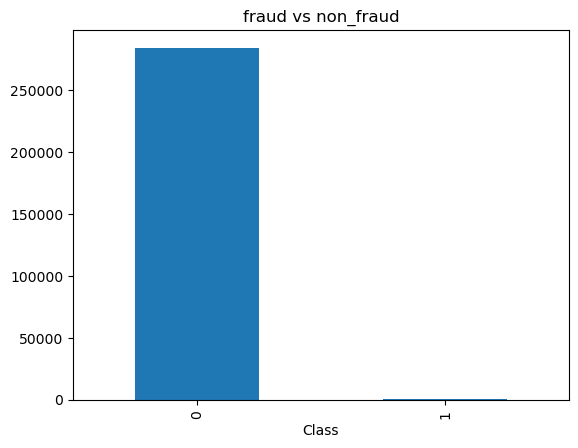

In [16]:
#visulization
import matplotlib.pyplot as plt
df['Class'].value_counts().plot(kind='bar')
plt.title("fraud vs non_fraud")
plt.show()